<a href="https://colab.research.google.com/github/TouyeAchille/lung-cancer-ct-detection-ai/blob/master/notebook_vit_efficientnetB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lung Cancer CT-Scan — ViT-Base/16 & EfficientNet-B3

**Pipeline :**
1. Chargement & inventaire des données (identique au notebook du collègue)
2. Dataset PyTorch + DataLoaders
3. Fonctions d'évaluation
4. **EfficientNet-B3** — Baseline (zero-shot) → Fine-Tuning → Comparaison
5. **ViT-Base/16** — Baseline (zero-shot) → Fine-Tuning → Comparaison
6. Comparaison finale des deux modèles

## 0. Setup

In [1]:
# Installer transformers pour ViT (HuggingFace)
!pip install transformers -q

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Fix conflit OpenMP Windows

import kagglehub
import glob
import random
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# HuggingFace — ViT
from transformers import ViTForImageClassification, ViTImageProcessor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f"Device utilisé  : {DEVICE}")

PyTorch version : 2.10.0+cu128
CUDA disponible : True
GPU : Tesla T4
Device utilisé  : cuda


## 1. Chargement & Inventaire des données

In [3]:
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
DATA_ROOT = Path(dataset_path) / "Data"

if not DATA_ROOT.exists():
    print(f"Le dossier {DATA_ROOT} n'existe pas.")
else:
    print(f"Dossier trouvé : {DATA_ROOT}")
    for split in ["train", "test", "valid"]:
        split_path = DATA_ROOT / split
        if split_path.exists():
            classes = sorted([d.name for d in split_path.iterdir() if d.is_dir()])
            print(f"   {split}/ → {len(classes)} classes : {classes}")

100%|██████████| 119M/119M [00:08<00:00, 13.8MB/s]

Extracting files...


Dossier trouvé : /root/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data
   train/ → 4 classes : ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
   test/ → 4 classes : ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
   valid/ → 4 classes : ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [4]:
CLASS_NAMES  = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
COLORS       = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
NUM_CLASSES  = len(CLASS_NAMES)

def get_class_from_folder(folder_name):
    for class_name in CLASS_NAMES:
        if folder_name == class_name or folder_name.startswith(class_name + '_'):
            return class_name
    return None

data_records = []
for split in ['train', 'valid', 'test']:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        continue
    for folder in sorted(split_dir.iterdir()):
        if not folder.is_dir():
            continue
        class_name = get_class_from_folder(folder.name)
        if class_name is None:
            continue
        for img_path in sorted(folder.glob('*.*')):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif']:
                data_records.append({
                    'path':       str(img_path),
                    'split':      split,
                    'class_name': class_name,
                    'label':      CLASS_LABELS[class_name],
                    'filename':   img_path.name
                })

df = pd.DataFrame(data_records)

summary = df.groupby(['class_name', 'split']).size().unstack(fill_value=0)
summary['TOTAL'] = summary.sum(axis=1)
summary.loc['TOTAL'] = summary.sum()
print(f"Total images trouvees : {len(df)}")
print(summary.to_string())

Total images trouvees : 1000
split                    test  train  valid  TOTAL
class_name                                        
adenocarcinoma            120    195     23    338
large.cell.carcinoma       51    115     21    187
normal                     54    148     13    215
squamous.cell.carcinoma    90    155     15    260
TOTAL                     315    613     72   1000


## 2. Dataset PyTorch & DataLoaders

In [5]:
# ── Transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(img_size=224, is_training=True):
    if is_training:
        return T.Compose([
            T.Resize((img_size + 32, img_size + 32)),
            T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.RandomRotation(degrees=15),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

print("Transforms définies")
print("   Train : augmentation + resize + normalize")
print("   Val/Test : resize + normalize")

Transforms définies
   Train : augmentation + resize + normalize
   Val/Test : resize + normalize


In [6]:
# ── Classe Dataset
class LungCTDataset(Dataset):

    def __init__(self, dataframe, transform=None, img_size=224):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['label']
        if self.transform:
            image = self.transform(image)
        else:
            image = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.ToTensor(),
            ])(image)
        return image, label

    def get_class_weights(self):
        counts = Counter(self.df['label'].values)
        total  = sum(counts.values())
        weights = {cls: total / count for cls, count in counts.items()}
        max_w   = max(weights.values())
        return {cls: w / max_w for cls, w in weights.items()}


# ── Splits ─────────────────────────────────────────────────────────────────
train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'valid']
test_df  = df[df['split'] == 'test']

# ── Datasets CNN (EfficientNet-B3 → 300×300) ──────────────────────────────
IMG_SIZE_B3 = 300   # EfficientNet-B3 attend 300×300
train_dataset_b3 = LungCTDataset(train_df, transform=get_transforms(IMG_SIZE_B3, is_training=True))
val_dataset_b3   = LungCTDataset(val_df,   transform=get_transforms(IMG_SIZE_B3, is_training=False))
test_dataset_b3  = LungCTDataset(test_df,  transform=get_transforms(IMG_SIZE_B3, is_training=False))

# ── Datasets ViT (224×224 via HuggingFace processor) ──────────────────────
VIT_MODEL_NAME = 'google/vit-base-patch16-224'
vit_processor  = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)

class LungCTDatasetViT(Dataset):
    """Dataset adapté pour ViT HuggingFace — retourne pixel_values."""

    def __init__(self, dataframe, processor, is_training=False):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.aug_tf = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.RandomRotation(degrees=15),
            T.ColorJitter(brightness=0.2, contrast=0.2),
        ]) if is_training else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.aug_tf:
            image = self.aug_tf(image)
        # Le processor HuggingFace gère resize + normalisation
        pixel_values = self.processor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        return pixel_values, int(row['label'])

train_dataset_vit = LungCTDatasetViT(train_df, vit_processor, is_training=True)
val_dataset_vit   = LungCTDatasetViT(val_df,   vit_processor, is_training=False)
test_dataset_vit  = LungCTDatasetViT(test_df,  vit_processor, is_training=False)

print("Datasets créés :")
print(f"  EfficientNet-B3 → Train: {len(train_dataset_b3)} | Val: {len(val_dataset_b3)} | Test: {len(test_dataset_b3)}")
print(f"  ViT-Base/16     → Train: {len(train_dataset_vit)} | Val: {len(val_dataset_vit)} | Test: {len(test_dataset_vit)}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Datasets créés :
  EfficientNet-B3 → Train: 613 | Val: 72 | Test: 315
  ViT-Base/16     → Train: 613 | Val: 72 | Test: 315


In [7]:
# ── DataLoaders
BATCH_SIZE   = 32
BATCH_SIZE_VIT = 16   # ViT est plus lourd en mémoire
NUM_WORKERS  = 0      # 0 pour Windows, augmenter sur Linux/Colab

# EfficientNet-B3
train_loader_b3 = DataLoader(train_dataset_b3, batch_size=BATCH_SIZE,     shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_b3   = DataLoader(val_dataset_b3,   batch_size=BATCH_SIZE,     shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_b3  = DataLoader(test_dataset_b3,  batch_size=BATCH_SIZE,     shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ViT
train_loader_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE_VIT, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_vit   = DataLoader(val_dataset_vit,   batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_vit  = DataLoader(test_dataset_vit,  batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Poids de classes (pour la loss pondérée, comme le collègue)
class_weights = train_dataset_b3.get_class_weights()
weights_tensor = torch.tensor(
    [class_weights[i] for i in range(NUM_CLASSES)], dtype=torch.float
).to(DEVICE)

print("DataLoaders prêts")
print(f"  EfficientNet-B3 → batch {BATCH_SIZE} | ViT → batch {BATCH_SIZE_VIT}")
print(f"\nPoids des classes :")
for i, w in class_weights.items():
    print(f"   {CLASS_NAMES[i]:30s} → {w:.3f}")

DataLoaders prêts
  EfficientNet-B3 → batch 32 | ViT → batch 16

Poids des classes :
   adenocarcinoma                 → 0.590
   large.cell.carcinoma           → 1.000
   normal                         → 0.777
   squamous.cell.carcinoma        → 0.742


## 3. Fonctions d'évaluation & d'entraînement

In [8]:
# ── evaluate_model
def evaluate_model(model, loader, device, class_names=CLASS_NAMES, model_type='cnn'):
    """
    model_type : 'cnn' (torchvision) ou 'vit' (HuggingFace)
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Évaluation", leave=False):
            images = images.to(device)
            if model_type == 'vit':
                outputs = model(pixel_values=images)
                logits  = outputs.logits
            else:
                logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    return {
        'accuracy':         accuracy_score(all_labels, all_preds),
        'report':           classification_report(all_labels, all_preds, target_names=class_names, output_dict=True),
        'confusion_matrix': confusion_matrix(all_labels, all_preds),
        'preds':  all_preds,
        'labels': all_labels,
        'probs':  all_probs,
    }


# ── plot_results
def plot_results(results, title, class_names=CLASS_NAMES, save_path=None):
    short = [c.split('.')[0][:12] for c in class_names]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Matrice de confusion normalisée
    cm      = results['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short, yticklabels=short, ax=axes[0])
    axes[0].set_title(f'Matrice de Confusion (normalisée)\nAccuracy : {results["accuracy"]*100:.1f}%')
    axes[0].set_ylabel('Réel'); axes[0].set_xlabel('Prédit')

    # F1 par classe
    report    = results['report']
    f1_scores = [report[c]['f1-score'] for c in class_names]
    bars = axes[1].bar(short, f1_scores, color=COLORS[:len(class_names)])
    axes[1].set_ylim(0, 1.15)
    axes[1].set_title(f'F1-Score par classe\nMacro F1 : {report["macro avg"]["f1-score"]:.3f}')
    axes[1].set_ylabel('F1-Score')
    for bar, val in zip(bars, f1_scores):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.02, f'{val:.2f}',
                     ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Helpers train/val epoch
def train_epoch_cnn(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    total = 0.0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def val_epoch_cnn(model, loader, criterion, device=DEVICE):
    model.eval()
    loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss    += criterion(out, labels).item()
            correct += (out.argmax(1) == labels).sum().item()
            n       += labels.size(0)
    return loss / len(loader), correct / n


# ── Helpers spécifiques ViT (HuggingFace gère la loss en interne) ─────────
def train_epoch_vit(model, loader, optimizer, device=DEVICE):
    model.train()
    total = 0.0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=imgs, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        total += outputs.loss.item()
    return total / len(loader)

def val_epoch_vit(model, loader, device=DEVICE):
    model.eval()
    loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(pixel_values=imgs, labels=labels)
            loss    += outputs.loss.item()
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            n       += labels.size(0)
    return loss / len(loader), correct / n


# ── Courbes d'apprentissage ────────────────────────────────────────────────
def plot_history(history, title, unfreeze_epoch=None, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontweight='bold')
    ep = range(1, len(history['train_loss']) + 1)

    axes[0].plot(ep, history['train_loss'], label='Train Loss', color='#e74c3c')
    axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='#3498db')
    if unfreeze_epoch:
        axes[0].axvline(unfreeze_epoch, color='gray', linestyle='--', lw=1,
                        label=f'Dégel backbone (ep.{unfreeze_epoch})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend()

    axes[1].plot(ep, [v * 100 for v in history['val_acc']], color='#2ecc71', marker='o', markersize=4)
    if unfreeze_epoch:
        axes[1].axvline(unfreeze_epoch, color='gray', linestyle='--', lw=1)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy (%)')
    axes[1].set_title('Accuracy (validation)'); axes[1].set_ylim(0, 105)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Fonctions evaluate_model, plot_results, train_epoch, val_epoch définies.")

Fonctions evaluate_model, plot_results, train_epoch, val_epoch définies.


---
# 🅰️ EFFICIENTNET-B3

> Architecture CNN avec compound scaling (profondeur × largeur × résolution)  
> **12M paramètres** | Input : **300×300** | Top-1 ImageNet : **81.6%**

## A1. EfficientNet-B3 — Baseline (zero-shot, sans fine-tuning)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 67.6MB/s]


EfficientNet-B3 chargé : 10,702,380 paramètres | Input 300×300

BASELINE — EfficientNet-B3 pré-entraîné (sans fine-tuning)


Évaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Accuracy  : 18.41%
Macro F1  : 0.1747
Macro Prec: 0.2277
Macro Rec : 0.2028

                         precision    recall  f1-score   support

         adenocarcinoma       0.42      0.09      0.15       120
   large.cell.carcinoma       0.14      0.35      0.20        51
                 normal       0.16      0.11      0.13        54
squamous.cell.carcinoma       0.18      0.26      0.21        90

               accuracy                           0.18       315
              macro avg       0.23      0.20      0.17       315
           weighted avg       0.26      0.18      0.17       315



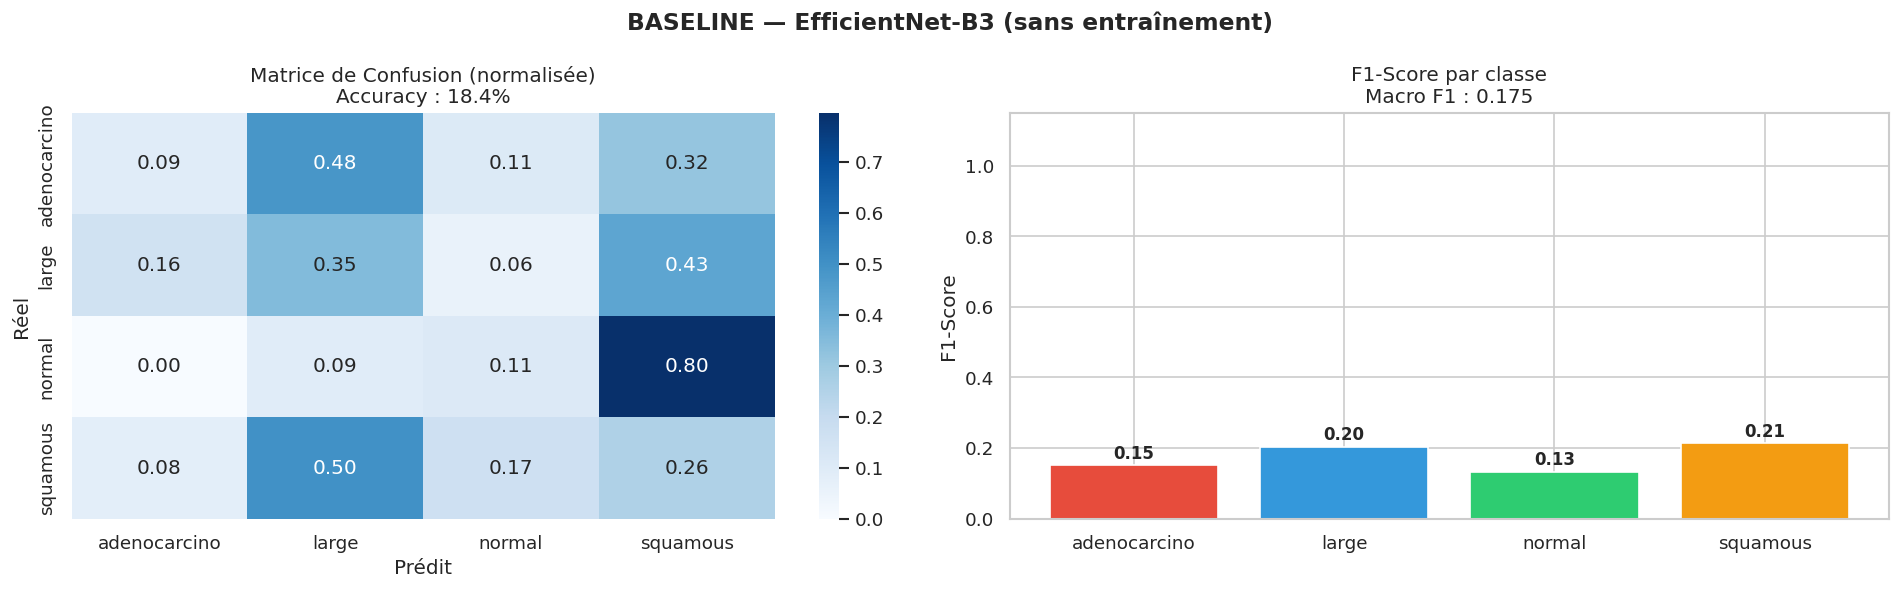

In [9]:
# ── Construction du modèle ─────────────────────────────────────────────────
def build_efficientnet_b3(num_classes=NUM_CLASSES, pretrained=True):
    weights = torchvision.models.EfficientNet_B3_Weights.DEFAULT if pretrained else None
    model   = torchvision.models.efficientnet_b3(weights=weights)
    in_features = model.classifier[1].in_features  # 1536
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

# ── Baseline ───────────────────────────────────────────────────────────────
baseline_b3 = build_efficientnet_b3(pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in baseline_b3.parameters())
print(f"EfficientNet-B3 chargé : {total_params:,} paramètres | Input {IMG_SIZE_B3}×{IMG_SIZE_B3}")

print("\nBASELINE — EfficientNet-B3 pré-entraîné (sans fine-tuning)")
baseline_results_b3 = evaluate_model(baseline_b3, test_loader_b3, DEVICE, model_type='cnn')

print(f"\nAccuracy  : {baseline_results_b3['accuracy']*100:.2f}%")
print(f"Macro F1  : {baseline_results_b3['report']['macro avg']['f1-score']:.4f}")
print(f"Macro Prec: {baseline_results_b3['report']['macro avg']['precision']:.4f}")
print(f"Macro Rec : {baseline_results_b3['report']['macro avg']['recall']:.4f}")
print()
print(classification_report(
    baseline_results_b3['labels'],
    baseline_results_b3['preds'],
    target_names=CLASS_NAMES
))

plot_results(
    baseline_results_b3,
    title="BASELINE — EfficientNet-B3 (sans entraînement)",
    save_path='b3_baseline_metrics.png'
)

## A2. EfficientNet-B3 — Fine-Tuning

In [10]:
# ── Hyperparamètres
EPOCHS        = 10
LR_HEAD       = 1e-3
LR_FULL       = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5
UNFREEZE_EPOCH_B3 = 3

criterion_b3 = nn.CrossEntropyLoss(weight=weights_tensor)

# ── Modèle ─────────────────────────────────────────────────────────────────
ft_model_b3 = build_efficientnet_b3(pretrained=True).to(DEVICE)

# Phase 1 : geler le backbone, entraîner seulement la tête
for p in ft_model_b3.features.parameters():
    p.requires_grad = False

optimizer_b3 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, ft_model_b3.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler_b3 = CosineAnnealingLR(optimizer_b3, T_max=UNFREEZE_EPOCH_B3 - 1)

# ── Boucle d'entraînement ──────────────────────────────────────────────────
history_b3 = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_acc_b3, best_state_b3, no_improve_b3 = 0.0, None, 0

print(f"Fine-Tuning EfficientNet-B3 ({EPOCHS} époques)...")

for epoch in range(1, EPOCHS + 1):
    # Dégeler le backbone à l'époque UNFREEZE_EPOCH_B3
    if epoch == UNFREEZE_EPOCH_B3:
        for p in ft_model_b3.features.parameters():
            p.requires_grad = True
        optimizer_b3 = torch.optim.Adam(ft_model_b3.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
        scheduler_b3 = CosineAnnealingLR(optimizer_b3, T_max=EPOCHS - UNFREEZE_EPOCH_B3 + 1)
        print(f"  Epoch {epoch}: backbone dégele (LR={LR_FULL})")

    t_loss         = train_epoch_cnn(ft_model_b3, train_loader_b3, criterion_b3, optimizer_b3)
    v_loss, v_acc  = val_epoch_cnn(ft_model_b3, val_loader_b3, criterion_b3)
    scheduler_b3.step()

    for k, v in zip(['train_loss', 'val_loss', 'val_acc'], [t_loss, v_loss, v_acc]):
        history_b3[k].append(v)

    flag = " *" if v_acc > best_acc_b3 else ""
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | Acc: {v_acc*100:.1f}%{flag}")

    if v_acc > best_acc_b3:
        best_acc_b3  = v_acc
        best_state_b3 = {k: v.clone() for k, v in ft_model_b3.state_dict().items()}
        no_improve_b3 = 0
    else:
        no_improve_b3 += 1
        if no_improve_b3 >= PATIENCE:
            print(f"Early stopping à l'époque {epoch}")
            break

ft_model_b3.load_state_dict(best_state_b3)
torch.save(best_state_b3, 'efficientnet_b3_finetuned.pth')
print(f"\nMeilleure Val Accuracy: {best_acc_b3*100:.1f}% — poids sauvegardés")

Fine-Tuning EfficientNet-B3 (10 époques)...


Train:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01/10 | Train: 1.2944 | Val: 1.2777 | Acc: 43.1% *


Train:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 02/10 | Train: 1.1452 | Val: 1.2029 | Acc: 43.1%
  Epoch 3: backbone dégele (LR=0.0001)


...

Epoch 08/10 | Train: 0.4861 | Val: 28.6608 | Acc: 75.0% *


Train:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 09/10 | Train: 0.4755 | Val: 42.4632 | Acc: 75.0%


Train:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 10/10 | Train: 0.4584 | Val: 13.1053 | Acc: 76.4% *

Meilleure Val Accuracy: 76.4% — poids sauvegardés


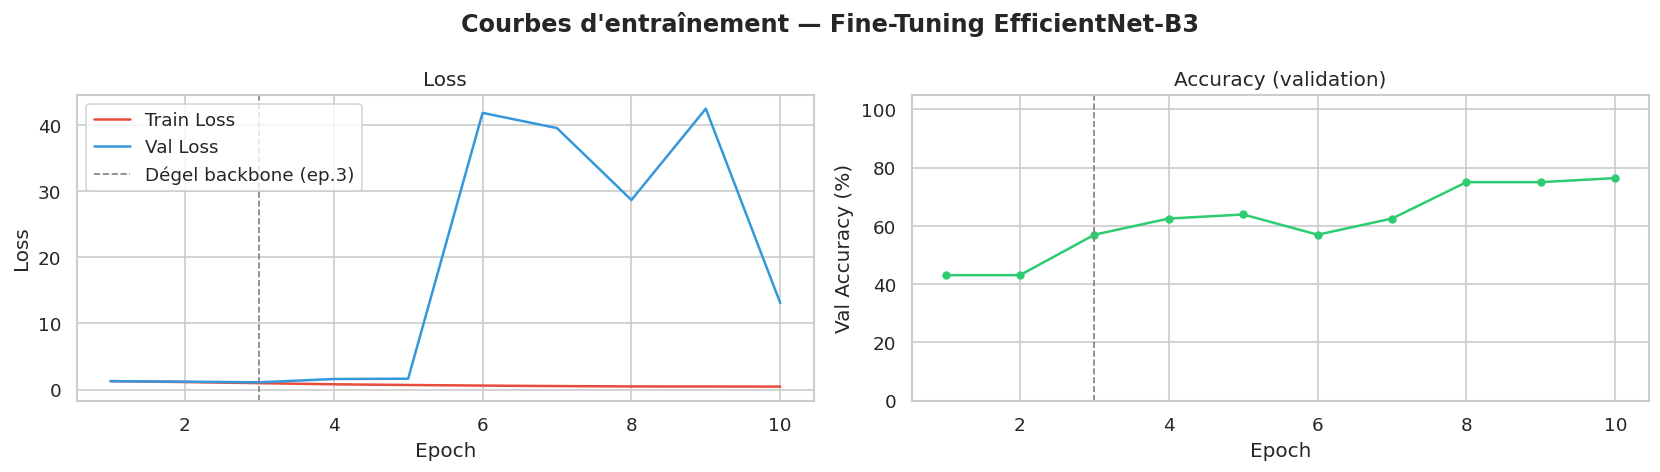

APRÈS FINE-TUNING — EfficientNet-B3


Évaluation:   0%|          | 0/10 [00:00<?, ?it/s]


Accuracy  : 73.33%
Macro F1  : 0.7559
Macro Prec: 0.7800
Macro Rec : 0.7418

                         precision    recall  f1-score   support

         adenocarcinoma       0.72      0.70      0.71       120
   large.cell.carcinoma       0.78      0.75      0.76        51
                 normal       1.00      0.78      0.88        54
squamous.cell.carcinoma       0.62      0.74      0.68        90

               accuracy                           0.73       315
              macro avg       0.78      0.74      0.76       315
           weighted avg       0.75      0.73      0.74       315



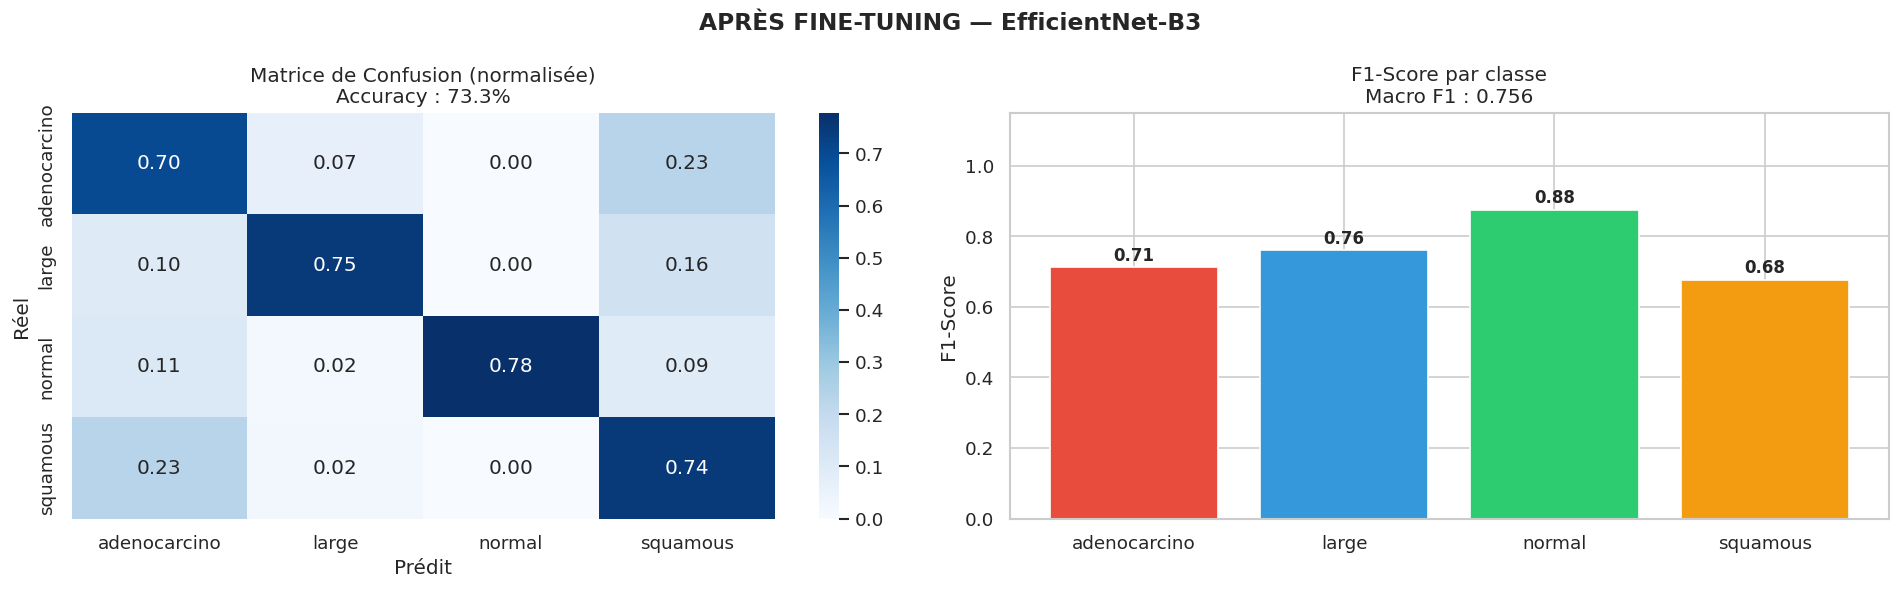

In [11]:
# ── Courbes d'apprentissage ─────────────────────────────────────────────
plot_history(
    history_b3,
    title="Courbes d'entraînement — Fine-Tuning EfficientNet-B3",
    unfreeze_epoch=UNFREEZE_EPOCH_B3,
    save_path='b3_training_curves.png'
)

# ── Évaluation après fine-tuning ────────────────────────────────────────
print("=" * 60)
print("APRÈS FINE-TUNING — EfficientNet-B3")
print("=" * 60)

ft_results_b3 = evaluate_model(ft_model_b3, test_loader_b3, DEVICE, model_type='cnn')

print(f"\nAccuracy  : {ft_results_b3['accuracy']*100:.2f}%")
print(f"Macro F1  : {ft_results_b3['report']['macro avg']['f1-score']:.4f}")
print(f"Macro Prec: {ft_results_b3['report']['macro avg']['precision']:.4f}")
print(f"Macro Rec : {ft_results_b3['report']['macro avg']['recall']:.4f}")
print()
print(classification_report(ft_results_b3['labels'], ft_results_b3['preds'], target_names=CLASS_NAMES))

plot_results(
    ft_results_b3,
    title="APRÈS FINE-TUNING — EfficientNet-B3",
    save_path='b3_finetuned_metrics.png'
)

In [12]:
# ── Tableau comparatif Baseline vs Fine-Tuned
b_rep = baseline_results_b3['report']
f_rep = ft_results_b3['report']

rows = [('Accuracy', baseline_results_b3['accuracy'], ft_results_b3['accuracy'])]
for avg in ['macro avg', 'weighted avg']:
    for m in ['precision', 'recall', 'f1-score']:
        rows.append((f"{avg} {m}", b_rep[avg][m], f_rep[avg][m]))

print(f"{'Metrique':<36} {'Baseline':>10} {'Fine-Tuned':>12} {'Gain':>8}")
print("-" * 68)
for name, bv, fv in rows:
    g = fv - bv
    print(f"  {name:<34} {bv:>10.4f} {fv:>12.4f} {('+' if g >= 0 else '')+f'{g:.3f}':>8}")

print("\nF1 par classe:")
for cls in CLASS_NAMES:
    bv, fv = b_rep[cls]['f1-score'], f_rep[cls]['f1-score']
    g = fv - bv
    print(f"  {cls:<34} {bv:>10.4f} {fv:>12.4f} {('+' if g >= 0 else '')+f'{g:.3f}':>8}")

Metrique                               Baseline   Fine-Tuned     Gain
--------------------------------------------------------------------
  Accuracy                               0.1841       0.7333   +0.549
  macro avg precision                    0.2277       0.7800   +0.552
  macro avg recall                       0.2028       0.7418   +0.539
  macro avg f1-score                     0.1747       0.7559   +0.581
  weighted avg precision                 0.2643       0.7501   +0.486
  weighted avg recall                    0.1841       0.7333   +0.549
  weighted avg f1-score                  0.1738       0.7376   +0.564

F1 par classe:
  adenocarcinoma                         0.1507       0.7119   +0.561
  large.cell.carcinoma                   0.2034       0.7600   +0.557
  normal                                 0.1319       0.8750   +0.743
  squamous.cell.carcinoma                0.2130       0.6768   +0.464


---
# 🅱️ VIT-BASE/16 (Vision Transformer)

> L'image est découpée en **patches de 16×16 px** (196 patches pour 224×224).  
> Chaque patch est traité comme un token, passé dans un **Transformer** avec attention multi-têtes.  
> **86M paramètres** | Input : **224×224** | Top-1 ImageNet : **81.3%**  
> Chargé via HuggingFace Transformers.

## B1. ViT-Base/16 — Baseline (zero-shot, sans fine-tuning)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT-Base/16 chargé : 85,801,732 paramètres | Input 224×224

BASELINE — ViT-Base/16 pré-entraîné (sans fine-tuning)


Évaluation:   0%|          | 0/20 [00:00<?, ?it/s]


Accuracy  : 27.94%
Macro F1  : 0.1553
Macro Prec: 0.1280
Macro Rec : 0.2614

                         precision    recall  f1-score   support

         adenocarcinoma       0.00      0.00      0.00       120
   large.cell.carcinoma       0.22      0.16      0.18        51
                 normal       0.00      0.00      0.00        54
squamous.cell.carcinoma       0.29      0.89      0.44        90

               accuracy                           0.28       315
              macro avg       0.13      0.26      0.16       315
           weighted avg       0.12      0.28      0.15       315



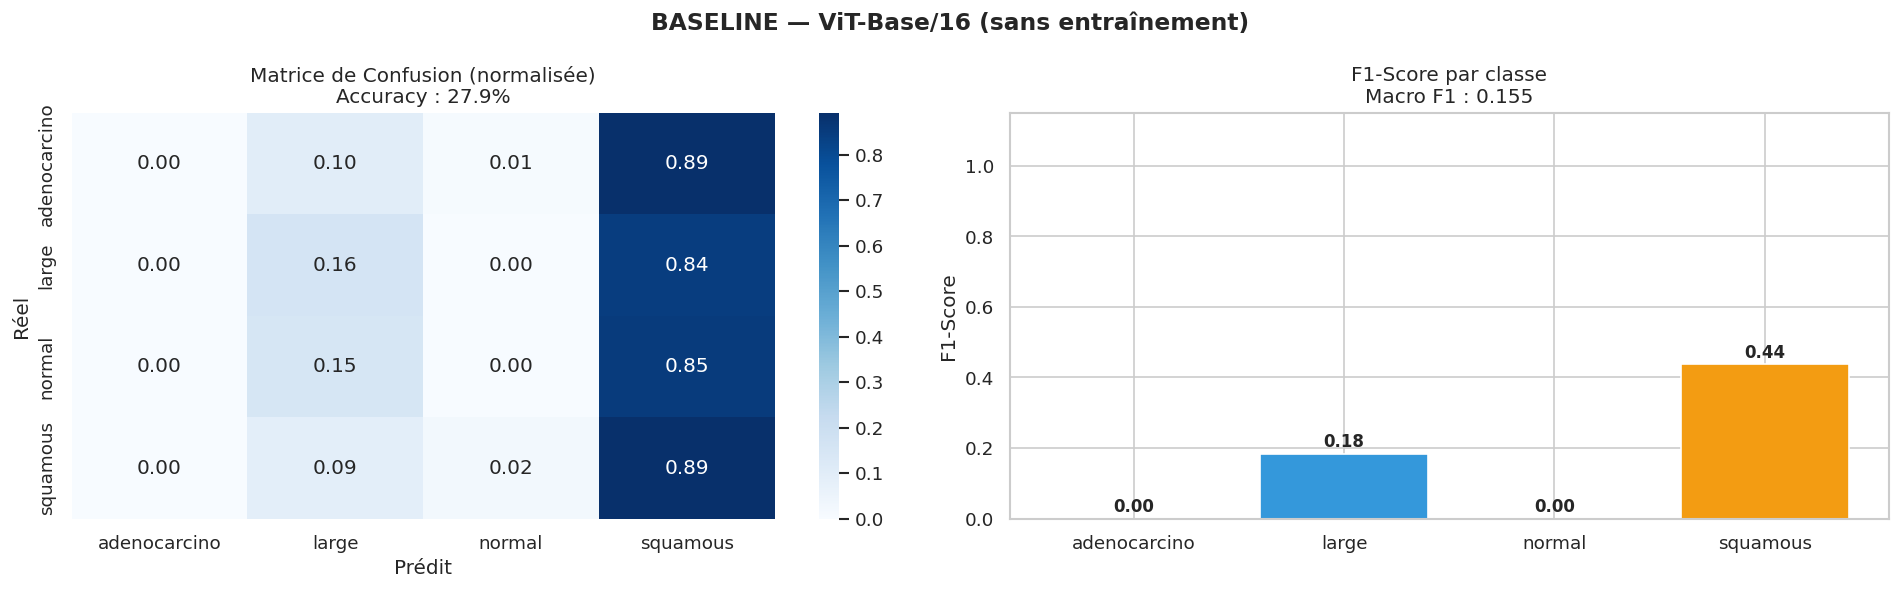

In [13]:
# ── Charger ViT pré-entraîné ───────────────────────────────────────────────
# ignore_mismatched_sizes=True est obligatoire car on change num_labels
baseline_vit = ViTForImageClassification.from_pretrained(
    VIT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(DEVICE)

total_params = sum(p.numel() for p in baseline_vit.parameters())
print(f"ViT-Base/16 chargé : {total_params:,} paramètres | Input 224×224")

print("\nBASELINE — ViT-Base/16 pré-entraîné (sans fine-tuning)")
baseline_results_vit = evaluate_model(baseline_vit, test_loader_vit, DEVICE, model_type='vit')

print(f"\nAccuracy  : {baseline_results_vit['accuracy']*100:.2f}%")
print(f"Macro F1  : {baseline_results_vit['report']['macro avg']['f1-score']:.4f}")
print(f"Macro Prec: {baseline_results_vit['report']['macro avg']['precision']:.4f}")
print(f"Macro Rec : {baseline_results_vit['report']['macro avg']['recall']:.4f}")
print()
print(classification_report(
    baseline_results_vit['labels'],
    baseline_results_vit['preds'],
    target_names=CLASS_NAMES
))

plot_results(
    baseline_results_vit,
    title="BASELINE — ViT-Base/16 (sans entraînement)",
    save_path='vit_baseline_metrics.png'
)

## B2. ViT-Base/16 — Fine-Tuning

In [14]:
# ── Nouveau modèle ViT pour le fine-tuning ─────────────────────────────────
ft_model_vit = ViTForImageClassification.from_pretrained(
    VIT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(DEVICE)

# Phase 1 : geler tout l'encoder, entraîner seulement la tête
UNFREEZE_EPOCH_VIT = 3

for name, param in ft_model_vit.named_parameters():
    param.requires_grad = False
for name, param in ft_model_vit.named_parameters():
    if 'classifier' in name or 'layernorm' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in ft_model_vit.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ft_model_vit.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# LR beaucoup plus faible pour ViT — essentiel pour ne pas détruire les poids
optimizer_vit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, ft_model_vit.parameters()),
    lr=1e-3, weight_decay=1e-2
)
scheduler_vit = CosineAnnealingLR(optimizer_vit, T_max=UNFREEZE_EPOCH_VIT - 1)

# ── Boucle d'entraînement ──────────────────────────────────────────────────
history_vit = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_acc_vit, best_state_vit, no_improve_vit = 0.0, None, 0

print(f"\nFine-Tuning ViT-Base/16 ({EPOCHS} époques)...")

for epoch in range(1, EPOCHS + 1):
    # Dégeler les 4 derniers blocs Transformer à l'époque UNFREEZE_EPOCH_VIT
    if epoch == UNFREEZE_EPOCH_VIT:
        for name, param in ft_model_vit.named_parameters():
            if any(f'encoder.layer.{i}' in name for i in [8, 9, 10, 11]):
                param.requires_grad = True
        optimizer_vit = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, ft_model_vit.parameters()),
            lr=2e-5, weight_decay=1e-2   # LR très faible pour le backbone ViT
        )
        scheduler_vit = CosineAnnealingLR(optimizer_vit, T_max=EPOCHS - UNFREEZE_EPOCH_VIT + 1)
        trainable = sum(p.numel() for p in ft_model_vit.parameters() if p.requires_grad)
        print(f"  Epoch {epoch}: backbone dégele — {trainable:,} params entraînables (LR=2e-5)")

    t_loss         = train_epoch_vit(ft_model_vit, train_loader_vit, optimizer_vit)
    v_loss, v_acc  = val_epoch_vit(ft_model_vit, val_loader_vit)
    scheduler_vit.step()

    for k, v in zip(['train_loss', 'val_loss', 'val_acc'], [t_loss, v_loss, v_acc]):
        history_vit[k].append(v)

    flag = " *" if v_acc > best_acc_vit else ""
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | Acc: {v_acc*100:.1f}%{flag}")

    if v_acc > best_acc_vit:
        best_acc_vit  = v_acc
        best_state_vit = {k: v.clone() for k, v in ft_model_vit.state_dict().items()}
        no_improve_vit = 0
    else:
        no_improve_vit += 1
        if no_improve_vit >= PATIENCE:
            print(f"Early stopping à l'époque {epoch}")
            break

ft_model_vit.load_state_dict(best_state_vit)
torch.save(best_state_vit, 'vit_base16_finetuned.pth')
print(f"\nMeilleure Val Accuracy: {best_acc_vit*100:.1f}% — poids sauvegardés")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Paramètres entraînables : 41,476 / 85,801,732 (0.0%)

Fine-Tuning ViT-Base/16 (10 époques)...


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01/10 | Train: 1.0510 | Val: 1.0388 | Acc: 45.8% *


...

Epoch 08/10 | Train: 0.3381 | Val: 0.7459 | Acc: 68.1% *


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 09/10 | Train: 0.3538 | Val: 0.7540 | Acc: 65.3%


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 10/10 | Train: 0.3224 | Val: 0.7556 | Acc: 65.3%

Meilleure Val Accuracy: 68.1% — poids sauvegardés


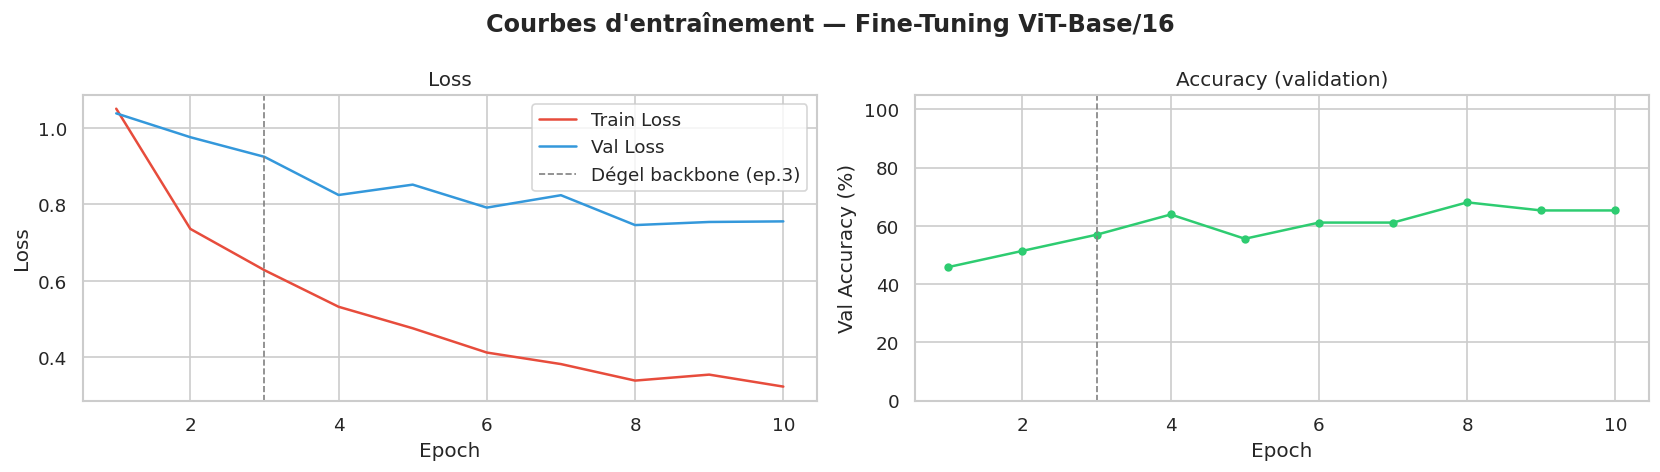

APRÈS FINE-TUNING — ViT-Base/16


Évaluation:   0%|          | 0/20 [00:00<?, ?it/s]


Accuracy  : 75.56%
Macro F1  : 0.7718
Macro Prec: 0.7996
Macro Rec : 0.7776

                         precision    recall  f1-score   support

         adenocarcinoma       0.67      0.85      0.75       120
   large.cell.carcinoma       0.71      0.82      0.76        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.82      0.46      0.59        90

               accuracy                           0.76       315
              macro avg       0.80      0.78      0.77       315
           weighted avg       0.77      0.76      0.75       315



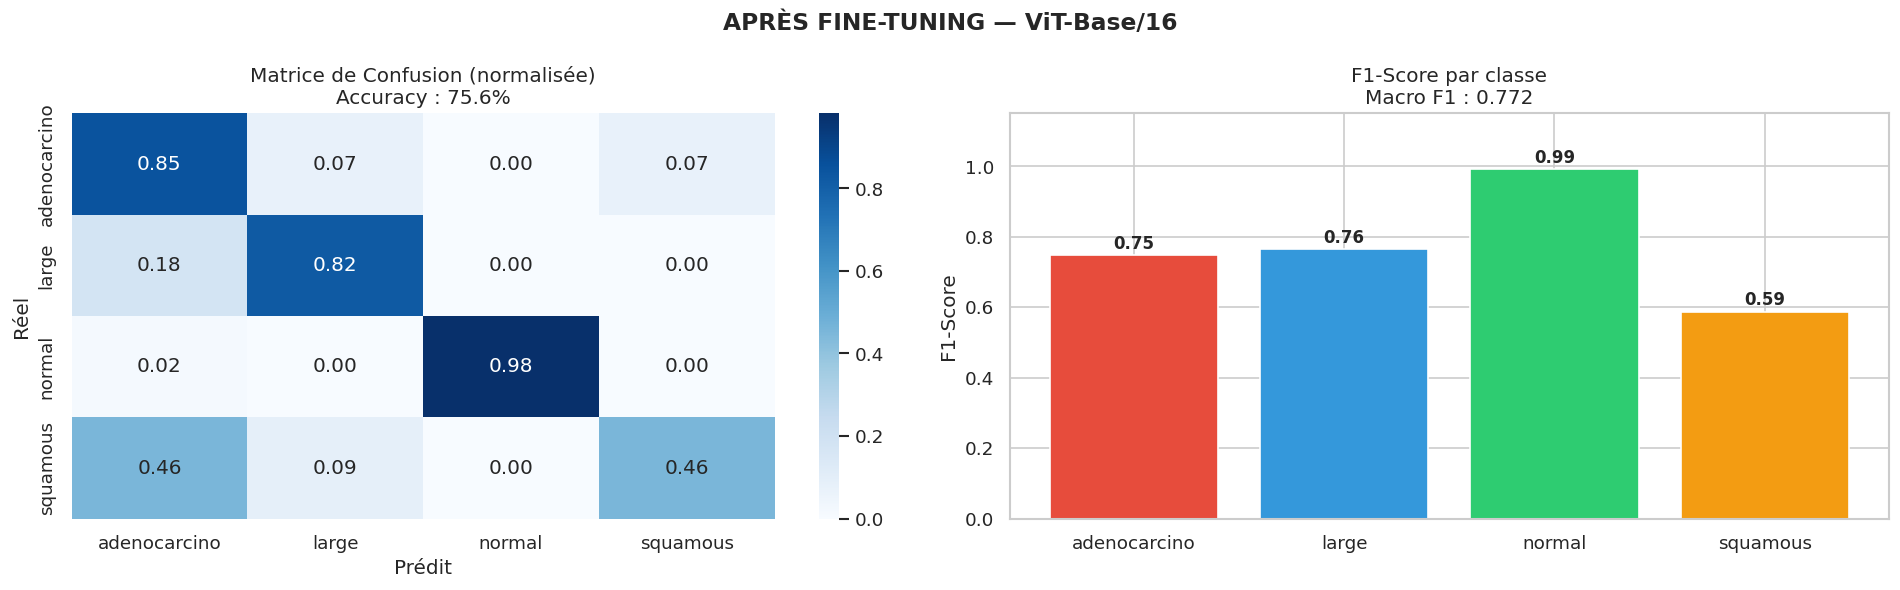

In [15]:
# ── Courbes d'apprentissage ────────────────────────────────────────────────
plot_history(
    history_vit,
    title="Courbes d'entraînement — Fine-Tuning ViT-Base/16",
    unfreeze_epoch=UNFREEZE_EPOCH_VIT,
    save_path='vit_training_curves.png'
)

# ── Évaluation après fine-tuning ──────────────────────────────────────────
print("=" * 60)
print("APRÈS FINE-TUNING — ViT-Base/16")
print("=" * 60)

ft_results_vit = evaluate_model(ft_model_vit, test_loader_vit, DEVICE, model_type='vit')

print(f"\nAccuracy  : {ft_results_vit['accuracy']*100:.2f}%")
print(f"Macro F1  : {ft_results_vit['report']['macro avg']['f1-score']:.4f}")
print(f"Macro Prec: {ft_results_vit['report']['macro avg']['precision']:.4f}")
print(f"Macro Rec : {ft_results_vit['report']['macro avg']['recall']:.4f}")
print()
print(classification_report(ft_results_vit['labels'], ft_results_vit['preds'], target_names=CLASS_NAMES))

plot_results(
    ft_results_vit,
    title="APRÈS FINE-TUNING — ViT-Base/16",
    save_path='vit_finetuned_metrics.png'
)

In [16]:
# ── Tableau comparatif Baseline vs Fine-Tuned ViT ─────────────────────────
b_rep = baseline_results_vit['report']
f_rep = ft_results_vit['report']

rows = [('Accuracy', baseline_results_vit['accuracy'], ft_results_vit['accuracy'])]
for avg in ['macro avg', 'weighted avg']:
    for m in ['precision', 'recall', 'f1-score']:
        rows.append((f"{avg} {m}", b_rep[avg][m], f_rep[avg][m]))

print(f"{'Metrique':<36} {'Baseline':>10} {'Fine-Tuned':>12} {'Gain':>8}")
print("-" * 68)
for name, bv, fv in rows:
    g = fv - bv
    print(f"  {name:<34} {bv:>10.4f} {fv:>12.4f} {('+' if g >= 0 else '')+f'{g:.3f}':>8}")

print("\nF1 par classe:")
for cls in CLASS_NAMES:
    bv, fv = b_rep[cls]['f1-score'], f_rep[cls]['f1-score']
    g = fv - bv
    print(f"  {cls:<34} {bv:>10.4f} {fv:>12.4f} {('+' if g >= 0 else '')+f'{g:.3f}':>8}")

Metrique                               Baseline   Fine-Tuned     Gain
--------------------------------------------------------------------
  Accuracy                               0.2794       0.7556   +0.476
  macro avg precision                    0.1280       0.7996   +0.672
  macro avg recall                       0.2614       0.7776   +0.516
  macro avg f1-score                     0.1553       0.7718   +0.617
  weighted avg precision                 0.1188       0.7749   +0.656
  weighted avg recall                    0.2794       0.7556   +0.476
  weighted avg f1-score                  0.1547       0.7455   +0.591

F1 par classe:
  adenocarcinoma                         0.0000       0.7473   +0.747
  large.cell.carcinoma                   0.1839       0.7636   +0.580
  normal                                 0.0000       0.9907   +0.991
  squamous.cell.carcinoma                0.4372       0.5857   +0.149


---
## 🏆 Comparaison finale : EfficientNet-B3 vs ViT-Base/16

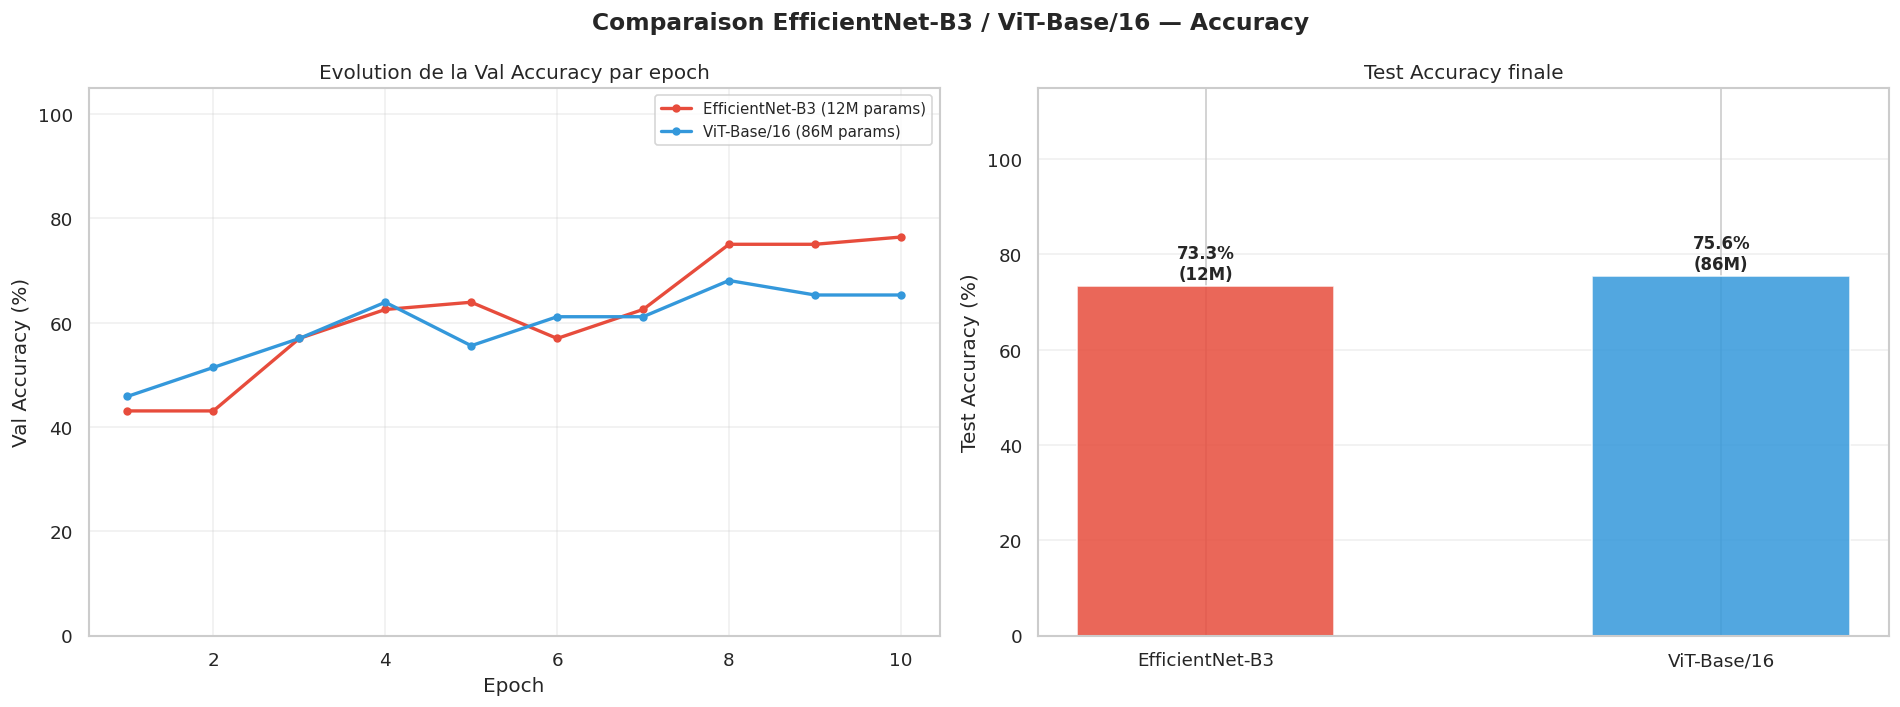

Figure sauvegardee : final_model_comparison.png


In [17]:
# ── Tableau final
models_data = {
    'EfficientNet-B3': {
        'val_acc':  history_b3['val_acc'],
        'test_acc': ft_results_b3['accuracy'],
        'color':    '#e74c3c',
        'params':   '12M'
    },
    'ViT-Base/16': {
        'val_acc':  history_vit['val_acc'],
        'test_acc': ft_results_vit['accuracy'],
        'color':    '#3498db',
        'params':   '86M'
    },
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison EfficientNet-B3 / ViT-Base/16 — Accuracy', fontsize=14, fontweight='bold')

# Courbes val accuracy
ax = axes[0]
for name, d in models_data.items():
    ax.plot(
        range(1, len(d['val_acc']) + 1),
        [v * 100 for v in d['val_acc']],
        color=d['color'], marker='o', markersize=4, linewidth=2,
        label=f"{name} ({d['params']} params)"
    )
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy (%)')
ax.set_title('Evolution de la Val Accuracy par epoch')
ax.set_ylim(0, 105); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Test accuracy finale
ax2    = axes[1]
names  = list(models_data.keys())
accs   = [d['test_acc'] * 100 for d in models_data.values()]
colors = [d['color'] for d in models_data.values()]
params = [d['params'] for d in models_data.values()]
bars   = ax2.bar(names, accs, color=colors, alpha=0.85, width=0.5)
ax2.set_ylim(0, 115); ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy finale'); ax2.grid(True, axis='y', alpha=0.3)
for bar, acc, p in zip(bars, accs, params):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{acc:.1f}%\n({p})', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : final_model_comparison.png")